# 卷积神经网络   
卷积神经网络（Convolutional Neural Network，CNN）是一种非常强大的深度学习模型，广泛应用于图像分析、目标检测、图像生成等任务中。CNN的核心思想是卷积操作和参数共享，卷积操作通过滑动滤波器（也称为卷积核）在输入数据上进行元素级的乘积求和运算，从而提取局部特征。通过多个滤波器的组合，CNN可以学习到不同层次的特征表示，从低级到高级的抽象特征。本节从传统全连接神经网络的缺陷为切入点，介绍了卷积神经网络的优势以及其基本组件，并使用pytorch构建卷积神经网络。

## 1. 全连接网络的缺陷  
传统深度前馈神经网络(也称全连接网络)的局限性之一是它不满足平移不变性，也就是说，在全连接网络看来，图像右上角有猫与位于图像中心的猫被视为不同对象，即使这是同一只猫。另外，全连接网络受对象大小的影响，如果训练集中大多数图像中的对象较大，而训练数据集图像中包含相同的对象但占据图像画面的比例较小，则全连接网络可能无法对图像进行正确分类。

接下来，我们通过具体示例来了解全连接网络的缺陷，继续使用在 PyTorch 构建深度神经网络中基于 Fashion-MNIST 数据集构建的模型，并预测给定图像对应的类别。​

1. 从训练图像中获取随机图像

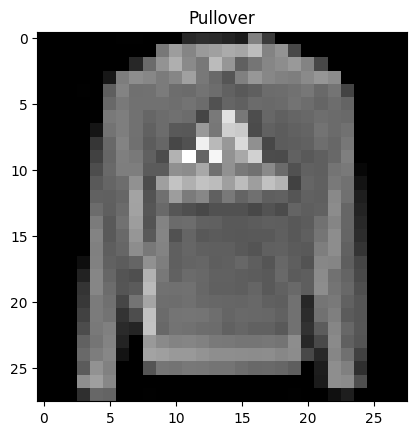

In [5]:
import matplotlib.pyplot as plt
from torch.utils import data
from torchvision import datasets
fmnist = datasets.FashionMNIST(root='data', train=True, download=True)
tr_images, tr_targets = fmnist.data, fmnist.targets
ix = 24150
plt.imshow(tr_images[ix], cmap='gray')
plt.title(fmnist.classes[tr_targets[ix]])
plt.show()

2. 将图像输入到训练完毕的神经网络中，对输入图像进行预处理，并且预测图象对应于各类别的概率：

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 1. 定义你指定的FashionMLP模型（完全按你的结构）
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        # 如果输入是 [784]，自动变成 [1,784]
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return self.model(x)

# 2. 初始化模型
model = FashionMLP()

# 3. 数据预处理（适配训练）
train_images = tr_images.float() / 255.0  # 归一化，和你预测时的预处理一致
train_images = train_images.view(-1, 28*28)  # 展平为784维
train_targets = tr_targets.long()  # 标签转为长整型

# 4. 构建数据加载器
train_dataset = TensorDataset(train_images, train_targets)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,  # 批量大小，兼顾速度和稳定性
    shuffle=True    # 打乱数据，提升训练效果
)

# 5. 定义损失函数和优化器（训练核心）
criterion = nn.CrossEntropyLoss()  # 多分类任务标准损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # 高效优化器

# 6. 执行训练（确保模型收敛到预期效果）
EPOCHS = 15  # 训练轮数，足够让模型学会识别Pullover
print("开始训练模型...")
model.train()  # 切换到训练模式
for epoch in range(EPOCHS):
    total_loss = 0.0
    for batch_imgs, batch_labels in train_loader:
        # 前向传播
        outputs = model(batch_imgs)
        loss = criterion(outputs, batch_labels)
        
        # 反向传播+更新权重
        optimizer.zero_grad()  # 清空梯度
        loss.backward()        # 计算梯度
        optimizer.step()       # 更新模型权重
        
        total_loss += loss.item()
    
    # 打印每轮损失（直观看到模型在学习）
    avg_loss = total_loss / len(train_loader)
    print(f"第 {epoch+1}/{EPOCHS} 轮训练，平均损失：{avg_loss:.4f}")
print("模型训练完成！")

开始训练模型...
第 1/15 轮训练，平均损失：0.5608


KeyboardInterrupt: 

In [ ]:
import numpy as np
img = tr_images[ix]/255.0
img = img.view(28*28)
img = img.to(device="cpu")

np_output = model(img).cpu().detach().numpy()
print(np.exp(np_output)/np.sum(np.exp(np_output)))

[[3.3236618e-04 1.0109250e-06 9.7158176e-01 2.0875226e-04 2.1441819e-02
  1.6578875e-08 6.4311880e-03 8.3930587e-09 3.0540220e-06 5.7014043e-10]]


从输出结果中，可以看到概率最高的是第 2 个索引，对应于 Pullover 类别。

3. 多次平移图像，并且记录预期结果

- 创建一个储存预测结果的列表

In [ ]:
preds = []

- 创建循环，将图像从原始位置向右移动

In [ ]:
for px in range(-5, 6):
    img = tr_images[ix].float() / 255.0# 归一化，和训练时一致
    
    img2 = np.roll(img, px, axis=1) # 水平滚动
    img3 = torch.Tensor(img2).view(28*28).to(device="cpu") # 转回Tensor并展平,将移动后的图像存储为张量对象并注册到设备中
    np_output = model(img3).cpu().detach().numpy() # 将移动后的图像输入模型进行预测，并将输出转换为NumPy数组
    preds.append(np.exp(np_output)/np.sum(np.exp(np_output))) # 将预测结果进行softmax处理，并存储在preds列表中

- 可视化模型对所有平移图像的预测( -5 像素到 +5 像素)：

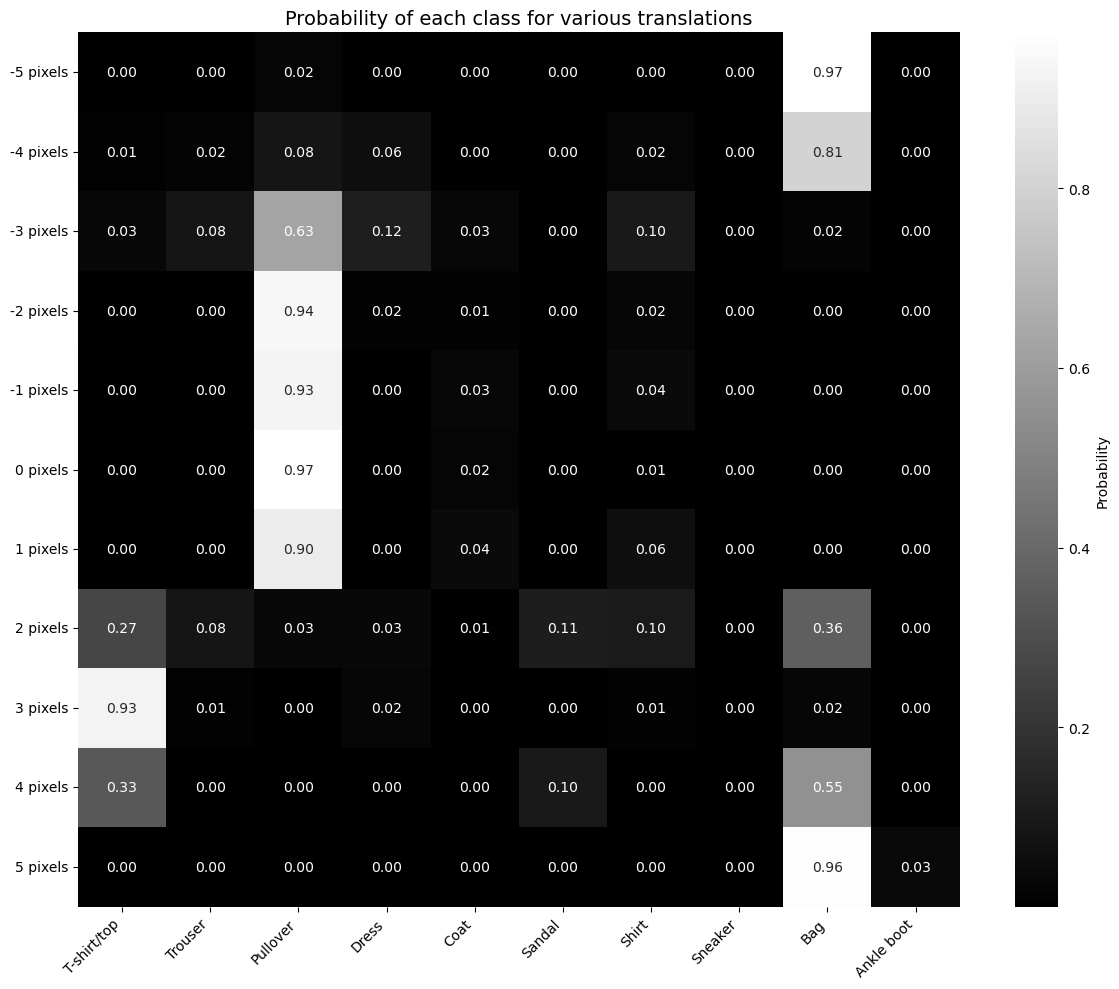

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 关键修复：将三维数组(11,1,10)展平为二维数组(11,10)
preds_2d = np.array(preds).squeeze()  # squeeze()移除所有长度为1的维度

# 绘制热力图
fig, ax = plt.subplots(1,1, figsize=(12,10))
plt.title('Probability of each class for various translations', fontsize=14)
sns.heatmap(
    preds_2d,  # 使用展平后的二维数组
    annot=True, 
    ax=ax, 
    fmt='.2f',  # 保留2位小数
    xticklabels=fmnist.classes,  # x轴：类别名称
    yticklabels=[f"{i} pixels" for i in range(-5,6)],  # y轴：偏移量
    cmap='gray',
    cbar_kws={'label': 'Probability'}  # 颜色条标签（可选优化）
)
# 优化标签显示（可选）
plt.xticks(rotation=45, ha='right')  # x轴标签旋转45度，避免重叠
plt.yticks(rotation=0)  # y轴标签水平显示
plt.tight_layout()  # 自动调整布局
plt.show()

图像内容并没有任何变化，因为对图像像素执行了平移，然而，当平移超过 2 个像素时，图像的预测类别发生了改变。这是因为在训练模型时，所有训练图像中的内容都处于中心位置，当使用偏离中心的平移图像进行测试时，模型将输出错误预测结果。这些问题的存在就是我们需要使用 CNN 的原因。

## 2. 卷积神经网络基本组件  
卷积神经网络 (Convolutional Neural Network, CNN) 是处理图像时最常用的架构，CNN 解决了传统全连接神经网络的主要缺陷，除了图像分类，还可以用于目标检测、图像分割、GAN 等等，本质上，在使用图像作为输入的网络中，都可以使用 CNN 架构。在本节中，我们将详细介绍 CNN 中卷积过程的工作原理。

### 2.1 卷积  
卷积本质上是两个矩阵之间的乘法(矩阵乘法是训练神经网络的关键要素)——通常一个矩阵具有较大尺寸，另一个矩阵则较小。为了确保我们对卷积过程有较好的理解，我们首先查看以下例子。

假设我们有两个矩阵用于执行卷积。给定矩阵 A 和矩阵 B 如下：

![11.1](../Images/11.1.png)

在进行卷积时，我们将较小的矩阵在较大的矩阵上滑动，在上述两个矩阵中，当较小的矩阵 B 需要在较大矩阵的整个区域上滑动时，会得到 9 次乘法运算，过程如下：

![11.2](../Images/11.2.png)

![11.3](../Images/11.3.png)

![11.4](../Images/11.4.png)

![11.5](../Images/11.5.png)

通常，我们把较小的矩阵 B 称为滤波器 (filter) 或卷积核 (kernel)，使用  $\odot$   表示卷积运算，较小矩阵中的值通过梯度下降被优化学习，卷积核中的值则为网络权重。在计算机视觉中，卷积后得到的矩阵，也称为特征图 (feature map)。

滤波器是在模型开始训练时随机初始化的权重矩阵，模型会在训练过程中学习滤波器的最佳权重值。一般来说，CNN 中的滤波器越多，模型能够学习到的图像特征就越多，在后续学习中我们会介绍滤波器学习到的内容。滤波器能够学习图像中的不同特征，例如，某个滤波器可能会学习到如何分辨猫的耳朵，并在图像包含猫的耳朵时能够卷积得到较高激活(即矩阵乘法值)。

卷积核的通道数与其所乘矩阵的通道数相等。例如，当图像输入形状为 5 x 5 x 3 时(其中 3 为图像通道数)，形状为 3 x 3 的卷积核也将具有 3 个通道，以便进行矩阵卷积运算：

![11.6](../Images/11.6.png)

处理具有三个通道的彩色图像时，与原始图像卷积的滤波器也需要具有三个通道(每次卷积的计算结果为单个输出矩阵)。如果滤波器与网络中间输出进行卷积，比如中间输出形状为 64 x 112 x 112，则每个滤波器都包括 64 个通道来获取输出；此外，如果有 512 个滤波器与中间层输出进行卷积，则卷积输出后的形状为 512 x 111 x 111。  
| 场景                     | 输入形状       | 滤波器规格（通道数 × 尺寸） | 滤波器数量 | 输出形状       | 核心逻辑                     |
|--------------------------|----------------|------------------------------|------------|----------------|------------------------------|
| 彩色图像卷积             | 3×112×112      | 3×3×3                        | 1          | 1×111×111      | 滤波器通道数 = 输入通道数    |
| 中间层卷积（单滤波器）| 64×112×112     | 64×3×3                       | 1          | 1×111×111      | 单个滤波器输出 1 个通道      |
| 中间层卷积（512 滤波器） | 64×112×112     | 64×3×3                       | 512        | 512×111×111    | 滤波器数量 = 输出通道数      |

需要注意的是，卷积并不等同于滤波，最直观的区别在于滤波后的图像大小不变，而卷积会改变图像大小，关于它们之间更详细的计算差异，并非本节重点，因此不再展开介绍。

### 2.2 步幅和填充  
#### 2.2.1 步幅  
在前面的示例中，卷积核每次计算时在水平和垂直方向只移动一个单位，因此可以说卷积核的步幅 (Strides) 为 (1, 1)，步幅越大，卷积操作跳过的值越多. 


#### 2.2.2 填充  
在前面的示例中，卷积操作对于输入矩阵的不同位置计算的次数并不相同，具体来说对于边缘的数值在卷积时，仅仅使用一次，而位于中心的值则会被多次使用，因此可能导致卷积错过图像边缘的一些重要信息。如果要增加对于图像边缘的考虑，我们将在输入矩阵的边缘周围的填充（Padding）0，下图展示了用 0 填充边缘后的矩阵进行的卷积运算，这种填充形式进行的卷积，称为 **same** 填充，填充后得到的矩阵大小为 $\lfloor \frac{d + 2p - k}{s} \rfloor + 1$，其中 $s$ 表示步幅，$p$ 表示填充大小，$k$ 表示滤波器尺寸。而未进行填充时执行卷积运算，也称为 **valid** 填充。

![11.7](../Images/11.7.png)

完成此操作后，可以在卷积操作的输出之上执行激活函数，CNN 支持常见的所有可用激活函数，包括 Sigmoid，ReLU 和 LeakyReLU 等。

### 2.3 池化  
研究了卷积的工作原理之后，我们将了解用于卷积操作之后的另一个常用操作：池化 (Pooling)。假设卷积操作的输出如下，为 2 x 2：

\begin{bmatrix}
29 & 28 \\
20 & 24
\end{bmatrix}

假设使用池化块(或者类比卷积核，我们也可以称之为池化核)为 2 x 2 的最大池化，那么将会输出 29 作为池化结果。假设卷积步骤的输出是一个更大的矩阵，如下所示：

\begin{bmatrix}
29 & 28 & 25 & 29 \\
20 & 24 & 30 & 26 \\
27 & 23 & 26 & 27 \\
24 & 25 & 23 & 31
\end{bmatrix}

当池化核为 2 x 2，且步幅为 2 时，最大池化会将此矩阵划分为 2 x 2 的非重叠块，并且仅保留每个块中最大的元素值，如下所示：  
![11.8](../Images/11.8.png)

从每个池化块中，最大池化仅选择具有最高值的元素。除了最大池化外，也可以使用平均池化，其将输出每个池化块中的平均值作为结果，在实践中，与其他类型的池化相比，最常使用的池化为最大池化。

### 2.3 卷积神经网络完整流程  
我们已经了解了卷积、滤波器和池化，以及它们对图像维度的影响。在 CNN 中通常还需要另一个关键组件——展平层。  


为了理解展平过程，使用上一节得到的池化层输出，将输出展平后输出如下：

\begin{bmatrix}
29 & 30 & 27 & 31
\end{bmatrix}

这样，就可以将 flatten 层视为全连接层的输入层，将其通过若干隐藏层后，获得用于预测图像类别的输出。综上，一个 CNN 的完整流程如下：

![11.9](../Images/11.9.png)

在上图中，可以看到 CNN 模型的整体流程，首先将图像通过多个滤波器进行卷积，然后进行池化(并数次重复执行卷积和池化过程)，然后最后的池化操作输出展平，这部分称为特征学习 (feature learning)。

特征学习部分基本上由卷积和池化操作构成，使用滤波器从图像中提取相关特征，使用池化聚合特征信息，从而减少展平层的节点数量。如果直接展平输入图像，即使图像大小仅为 300 x 300=90000 像素，如果在隐藏层中有 1000 个神经节点，则在隐藏层就大约需要 900000x1000=90000000 个参数，计算量巨大。而卷积和池化有助于减少图像特征数量，降低计算量。最后，网络的分类 (classification) 部分类似于在使用 PyTorch 构建神经网络中介绍的全连接神经网络。

## 3. 卷积和池化相比全连接网络的优势

传统神经网络的缺点之一是每个像素都具有不同的权重。因此，如果这些权重要用于除原始像素以外的相邻像素，则神经网络得到的输出将不是非常准确。在 CNN 中，图像中的像素共享由每个卷积核构成的权重，相比全连接网络具有以下优势：

- 参数共享：在卷积层中，权重参数被共享，这意味着每个卷积核在整个输入图像上进行滑动并提取特征，这种参数共享的方式显著减少了需要学习的参数数量，降低了模型复杂度，从而减少了过拟合的风险


- 局部感知和空间结构：卷积层通过使用局部感知域(感受野)的方式来识别图像中的特征，利用了图像的空间结构信息，这使得卷积神经网络在处理图像等二维数据时能够更好地捕捉到图像的局部特征和空间关系，从而提高了图像处理的效果

- 参数量减少：由于卷积层采用参数共享的机制，卷积神经网络通常比全连接网络具有更少的参数量，这不仅减少了训练网络所需的计算资源和时间，而且降低了过拟合的风险，有助于更好地泛化到新的数据集

- 平移不变性：卷积操作具有平移不变性，也就是说，当输入图像发生平移时，卷积层的输出不会改变，这种平移不变性使得卷积神经网络对于图像中的平移和位置变化具有鲁棒性，可以更好地处理具有不同位置和尺度的图像

- 降低计算复杂度：由于参数共享和局部感知机制，卷积神经网络的计算复杂度相对较低，这使得 CNN 在处理大规模图像数据时比全连接网络更高效，并且适用于部署在资源受限的设备上，如移动设备和嵌入式系统

接下来，我们从卷积和池化角度理解感受野，感受野是卷积神经网络中每个网络层输出的特征图中的单个元素映射回原始输入特征中的区域大小，假设我们对形状为 100 x 100 的图像执行两次卷积池化操作，两个卷积池化操作结束时的输出的形状为 25 x 25 (假设在卷积操作时使用填充操作)，25 x 25 的输出中的每个单元对应于原始图像中尺寸为 4 x 4 的部分。通常网络层越深，其输出特征的元素对应感受野越大。

## 4. 使用pytorch构建卷积神经网络  
CNN 是计算机视觉的基础模块之一，在了解其工作原理后，本节中，我们通过代码了解 CNN 前向传播过程中的计算流程。

首先，我们使用 PyTorch 在一个简单数据示例上构建一个 CNN 架构，然后通过在 Python 中从零开始构建前向传播来验证输出结果。

### 4.1 使用Pytorch构建CNN架构  
1. 首先，导入相关的库并创建数据集：

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
device = "cpu"

X_train = torch.tensor([[[[1,2,3,4],[2,3,4,5],
                          [5,6,7,8],[1,3,4,5]]],[[[-1,2,3,-4],[2,-3,4,5],
                                                  [-5,6,-7,8],[-1,-3,-4,-5]]]]).to(device).float()
X_train /= 8
y_train = torch.tensor([[0],[1]]).to(device).float()                                                                       

>需要注意的是，与 Keras 等机器学习库不同，PyTorch 期望输入的形状为 N x C x H x W，其中 N 是图像数量(批大小)，C 是通道数，H 是高度，W 是宽度。

将输入数据除以最大输入值缩放输入数据集，使其范围在 -1 到 +1 之间。以上输入数据集的形状为 (2,1,4,4)，因为有两个数据点，每个数据点的形状为 4 x 4 并且有 1 个通道。

2. 定义模型架构：

In [2]:
def get_model():
    model = nn.Sequential(
        nn.Conv2d(1, 1, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(1, 1),
        nn.Sigmoid(),
    ).to(device)
    loss_fn = nn.BCELoss()
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

在以上模型中，指定输入图像中有 1 个通道，使用 nn.Conv2d 方法指定卷积后包括 1 个通道(大小为 3 x 3 的滤波器)，使用 nn.MaxPool2d 执行最大池化，使用 nn.ReLU() 执行 ReLU 激活，然后展平激活值并连接到输出层，输出层中包含一个神经元。由于输出为二分类问题，因此使用二元交叉熵损失 nn.BCELoss()，还指定使用学习率为 0.001 的 Adam 优化器进行优化。

3. 调用 get_model() 函数初始化模型、损失函数 (loss_fn) 和优化器后，使用 torch_summary (可以使用 pip install torch_summary 命令安装 torch_summary 库)查看模型架构摘要： 

In [ ]:
import torch
from torchsummary import summary

device = torch.device("cpu") 

# 2. 获取模型并显式移到CPU（关键步骤！）
model, loss_fn, optimizer = get_model()
model = model.to(device)  # 把模型参数强制放到CPU

summary(model, input_size=tuple(X_train.shape[1:]), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1              [-1, 1, 2, 2]              10
         MaxPool2d-2              [-1, 1, 1, 1]               0
              ReLU-3              [-1, 1, 1, 1]               0
           Flatten-4                    [-1, 1]               0
            Linear-5                    [-1, 1]               2
           Sigmoid-6                    [-1, 1]               0
Total params: 12
Trainable params: 12
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


接下来，我们介绍每一层网络层的来源。Conv2d类的参数如下：  
![11.10](../Images/11.10.png)

在示例中，指定卷积核大小 (kernel_size) 为 3，输出通道数 (out_channels) 为 1 (即滤波器数量为 1)，其中初始(输入)通道的数量为 1。对于每个输入图像，形状为 1 x 4 x 4 的输入使用滤波器尺寸为 3x3 的卷积，因此，输出形状为 1 x 2 x 2。网络包含 10 个参数( 3 x 3 = 9 个权重参数和 1 个卷积核偏置)。而 MaxPool2d、ReLU 和 Flatten 层没有参数，因为这些计算并不涉及权重或偏置。4×4 → 卷积 → 2×2 → 池化 → 1×1 → Flatten → Linear

全连接层有 2 个参数( 1 个权重和 1 个偏置)，因此，共有 12 个参数( 10 个来自卷积操作，2 个来自全连接层)。

4. 重用在使用 PyTorch 构建神经网络中的代码训练模型，使用 PyTorch 构建深度神经网络，其中定义了训练批数据的函数 train_batch()；然后，获取 DataLoader 并在 2,000 个 epoch 上对其进行训练。

In [6]:
def train_batch(x, y, model, optimizer, loss_fn):
    model.train()
    prediction = model(x)
    print(prediction)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()  # 别忘了清空梯度，否则会累积！
    return batch_loss.item()

通过使用 TensorDataset 方法指定数据集，然后使用 DataLoader 加载数据集定义训练 DataLoader：

In [7]:
trn_dl = DataLoader(TensorDataset(X_train, y_train))

在以上代码中，直接利用 TensorDataset 方法，该方法提供与输入数据对应的对象。接下来，训练模型：

In [8]:
for epoch in range(2000):
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model,optimizer, loss_fn)

tensor([[0.4945]], grad_fn=<SigmoidBackward0>)
tensor([[0.4925]], grad_fn=<SigmoidBackward0>)
tensor([[0.4921]], grad_fn=<SigmoidBackward0>)
tensor([[0.4936]], grad_fn=<SigmoidBackward0>)
tensor([[0.4915]], grad_fn=<SigmoidBackward0>)
tensor([[0.4955]], grad_fn=<SigmoidBackward0>)
tensor([[0.4912]], grad_fn=<SigmoidBackward0>)
tensor([[0.4981]], grad_fn=<SigmoidBackward0>)
tensor([[0.4910]], grad_fn=<SigmoidBackward0>)
tensor([[0.5014]], grad_fn=<SigmoidBackward0>)
tensor([[0.4909]], grad_fn=<SigmoidBackward0>)
tensor([[0.5053]], grad_fn=<SigmoidBackward0>)
tensor([[0.4908]], grad_fn=<SigmoidBackward0>)
tensor([[0.5099]], grad_fn=<SigmoidBackward0>)
tensor([[0.4908]], grad_fn=<SigmoidBackward0>)
tensor([[0.5152]], grad_fn=<SigmoidBackward0>)
tensor([[0.4907]], grad_fn=<SigmoidBackward0>)
tensor([[0.5213]], grad_fn=<SigmoidBackward0>)
tensor([[0.4907]], grad_fn=<SigmoidBackward0>)
tensor([[0.5281]], grad_fn=<SigmoidBackward0>)
tensor([[0.4906]], grad_fn=<SigmoidBackward0>)
tensor([[0.53

5. 利用第一个数据点执行前向传递：

In [9]:
print(model(X_train[:1]))

tensor([[0.0035]], grad_fn=<SigmoidBackward0>)


在下一节中，我们将了解 CNN 中的前向传播工作原理，并从零开始构建 CNN 前向传播流程，验证本节模型计算结果。

### 4.2 验证CNN输出  
在本节中，通过实现 CNN 的前向传播过程来验证从模型中获得的输出，本节仅用于帮助了解 CNN 的工作原理，而无需在实际应用场景中执行。

1. 提取上一小节架构的卷积层和全连接层的权重和偏置。

In [10]:
print(list(model.children()))

[Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1)), MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False), ReLU(), Flatten(start_dim=1, end_dim=-1), Linear(in_features=1, out_features=1, bias=True), Sigmoid()]


提取模型中的所有层对应的 weights 属性：

In [11]:
(cnn_w, cnn_b), (lin_w, lin_b) = [(layer.weight.data, layer.bias.data) for layer in model if hasattr(layer, 'weight')]

在以上代码中，hasattr(layer,'weight') 会返回一个布尔值用于指示网络层是否包含权重属性。

只有卷积 (Conv2d) 层和全连接层包含参数的网络层，分别保存为 cnn_w 和 cnn_b 以及 lin_w 和 lin_b。cnn_w 的形状为 1 x 1 x 3 x 3，对应于具有一个通道、形状为 3 x 3 的一个滤波器，cnn_b 的形状为 `1，对应于此滤波器的偏置值。

2. 要对输入值执行 cnn_w 卷积运算，必须初始化一个零矩阵用于存储计算结果 (sumprod)，其中高度为 h_i - h_k + 1，宽度为 w_i - w_k + 1，其中 h_i 表示输入高度，h_k 表示滤波器高度，w_i 表示输入宽度，w_k 表示滤波器宽度：

In [12]:
h_im, w_im = X_train.shape[2:]
h_conv, w_conv = cnn_w.shape[2:]
sumprod = torch.zeros((h_im - h_conv + 1, w_im - w_conv + 1))

3. 接下来，我们通过模拟卷积过程对输入数据执行卷积，沿着行和列执行矩阵乘法(卷积)，首先将滤波器 (cnn_w) 形状由 1 x 1 x 3 x 3 重塑为 3 x 3，执行卷积后添加滤波器偏置项 (cnn_b)，填充到结果 sumprod 中：

In [13]:
for i in range(h_im - h_conv + 1):
    for j in range(w_im - w_conv + 1):
        img_subset = X_train[0, 0, i:(i+3), j:(j+3)]
        model_filter = cnn_w.reshape(3,3)
        val = torch.sum(img_subset*model_filter) + cnn_b
        sumprod[i,j] = val

在以上代码中，img_subset 存储了与滤波器执行卷积的输入部分。假设输入形状为 4 x 4，滤波器形状为 3 x 3，则输出形状为 2 x 2，sumprod 的输出如下：

In [14]:
print(sumprod)

tensor([[-2.5718, -3.3442],
        [-0.9325, -1.9466]])


4. 在输出 (sumprod) 上使用最大池化 (MaxPooling)，然后执行 ReLU 激活。 

对输出执行池化操作：

In [15]:
pooling_layer_output = torch.max(sumprod)

通过将输出最小值限制为 0，模拟 ReLU 激活函数：

In [16]:
print(pooling_layer_output.clamp_min_(0))

tensor(0.)


5. 通过线性激活传递以上输出： 

In [17]:
intermediate_output_value = pooling_layer_output * lin_w + lin_b

6. 由于使用二元交叉熵损失函数，因此通过 sigmoid 函数计算输出结果：

In [18]:
print(torch.sigmoid(intermediate_output_value))

tensor([[0.0035]])


使用以上代码可以得到与使用 PyTorch 的 forward 方法相同输出结果，从而验证了 CNN 的计算流程。

## 小结  
卷积神经网络 (Convolutional Neural Network, CNN) 是一种广泛应用的深度学习模型。通过参数共享、局部感知和空间结构等优势，能够更好地处理图像数据，并在图像识别、目标检测和图像生成等任务中展现出强大的能力。在本节中，介绍了卷积的计算方法以及卷积神经网络的基本组件，并使用 PyTorch 构建了卷积神经网络以深入了解其工作原理。​
​